In [1]:
import pandas as pd

# Cargar datasets
df_noticias = pd.read_csv("datos/noticias_agricolas.csv")
df_plagas = pd.read_csv("datos/reporte_plagas.csv")
df_precios = pd.read_csv("datos/precios_mercado.csv") 

In [2]:
# Ver estructura
df_noticias.head()

,id_noticia,Alemania,Argentina,Australia,Brasil,Canadá,España,Estados Unidos,India,Italia,...,China,categoria,contenido,Año,Mes,Día,fuente,impacto_cultivos,severidad,titular
0,NEWS6582,0,0,0,0,0,1,0,0,1,...,0,clima,Eventos climáticos extremos están afectando la...,2021,septiembre,23,Bloomberg Commodities,Café,media,Sequía afecta proyecciones de cosecha en Kenia
1,NEWS8516,0,0,0,0,0,1,0,0,0,...,0,clima,Eventos climáticos extremos están afectando la...,2022,octubre,23,World Grain,Maíz,baja,Heladas tardías dañan frutales en China
2,NEWS9993,0,0,0,0,0,0,0,0,1,...,0,clima,Eventos climáticos extremos están afectando la...,2021,diciembre,22,Meat+Poultry,Maíz,alta,Ola de calor reduce rendimientos de Maíz
3,NEWS2701,0,0,0,0,0,0,0,0,0,...,0,clima,Eventos climáticos extremos están afectando la...,2022,marzo,9,Farm Journal,trigo,baja,Inundaciones devastan cultivos en la región
4,NEWS2755,0,0,0,0,0,0,0,0,0,...,0,comercio,El gobierno de Alemania ha anunciado nuevas me...,2023,marzo,7,AgriCensus,todos,baja,Nueva política agrícola en Alemania busca mejo...


In [3]:
df_plagas.head()

,Año,Mes,Día,Area_afectada,Cultivo,Eficacia,Pais,Perdida_estimada,Plaga_detectada,Region,Severidad,Tratamiento_Aplicado
0,2020,enero,1,2745,Arroz,93,China,26,Barrenador del tallo,Región Principal,Media,Químico (Epoxiconazole)
1,2020,enero,13,3943,Caña de azúcar,97,Francia,17,Chinche marrón,Región Principal,Crítica,Cultural (Control manual)
2,2020,enero,15,10,Maíz,82,Brasil,38,Oruga militar tardía,Cerrado,Alta,Cultural (Fecha de siembra ajustada)
3,2020,enero,18,3064,Maíz,83,Brasil,3,Barrenador del tallo,Mata Atlántica,Crítica,Biológico (Trichogramma spp.)
4,2020,enero,23,995,Soja,75,Argentina,2,Langosta,Patagonia,Media,Biológico (Trichogramma spp.)


In [4]:
df_precios.head()

,fecha,pais,producto,precio_usd_ton,volumen_operado_ton,tendencia_30_dias,mercado_principal,precio_min_mes,precio_max_mes
0,2021-01-01,Argentina,Carne_bovina,4299.14,127922,subiendo,UE,3844.74,4517.42
1,2021-01-01,Argentina,Arroz,330.04,73231,subiendo,Sudeste Asiático,310.10,359.86
2,2021-01-01,Argentina,Maíz,210.36,11666,bajando,Japón,200.56,238.83
3,2021-01-01,Brasil,Maíz,212.91,195579,subiendo,Oriente Medio,200.25,243.04
4,2021-01-01,Brasil,Leche,356.41,136137,subiendo,UE,348.39,390.03


In [5]:
df_noticias.isnull().sum()

id_noticia          0
Alemania            0
Argentina           0
Australia           0
Brasil              0
Canadá              0
España              0
Estados Unidos      0
India               0
Italia              0
Francia             0
Kenia               0
México              0
Nueva Zelanda       0
Rusia               0
China               0
categoria           0
contenido           0
Año                 0
Mes                 0
Día                 0
fuente              0
impacto_cultivos    0
severidad           0
titular             0
dtype: int64

In [6]:
df_plagas.isnull().sum()

Año                     0
Mes                     0
Día                     0
Area_afectada           0
Cultivo                 0
Eficacia                0
Pais                    0
Perdida_estimada        0
Plaga_detectada         0
Region                  0
Severidad               0
Tratamiento_Aplicado    0
dtype: int64

In [7]:
df_precios.isnull().sum()

fecha                  0
pais                   0
producto               0
precio_usd_ton         0
volumen_operado_ton    0
tendencia_30_dias      0
mercado_principal      0
precio_min_mes         0
precio_max_mes         0
dtype: int64

Como podemos ver, no hay valores nulos en ninguno, asi que vamos a continuar

## Procesamiento de lenguaje natural (NLP)


### Extracción de entidades: plagas, cultivos, países, fechas

Muchos de los datos a extraer ya lo hemos hecho en el Power Bi, nos hemos dado cuenta que hay datos que si podemos procesar, como es un pais mas que no se refleja en el One Hot Encoder realizado

In [8]:
paises = [
    "alemania", "argentina", "australia", "brasil", "canadá",
    "españa", "estados unidos", "india", "italia",
    "francia", "kenia", "méxico", "nueva zelanda",
    "rusia", "china"
]

In [9]:
import string

def limpiar_texto(texto):
    texto = texto.lower()
    for signo in string.punctuation:
        texto = texto.replace(signo, "")
    return texto

df_noticias["contenido_limpio"] = df_noticias["contenido"].apply(limpiar_texto)

In [10]:
def extraer_primero(texto, lista):
    for palabra in lista:
        if palabra in texto:
            return palabra
    return "Sin especificar"

df_noticias["pais_detectado"] = df_noticias["contenido_limpio"].apply(lambda x: extraer_primero(x, paises))

In [11]:
df_noticias[["contenido_limpio", "pais_detectado"]].head(60)

,contenido_limpio,pais_detectado
0,eventos climáticos extremos están afectando la...,kenia
1,eventos climáticos extremos están afectando la...,china
2,eventos climáticos extremos están afectando la...,india
3,eventos climáticos extremos están afectando la...,china
4,el gobierno de alemania ha anunciado nuevas me...,alemania
5,el gobierno de alemania ha anunciado nuevas me...,alemania
6,el gobierno de argentina ha anunciado nuevas m...,argentina
7,el gobierno de argentina ha anunciado nuevas m...,argentina
8,el gobierno de argentina ha anunciado nuevas m...,argentina
9,el gobierno de australia ha anunciado nuevas m...,australia


In [12]:
# Unimos los paises a nuestro One Hot Encoder
for pais in df_noticias["pais_detectado"].unique():
    col = pais.title()
    
    if col in df_noticias.columns:
        df_noticias.loc[df_noticias["pais_detectado"] == pais, col] = 1

In [13]:
df_noticias = df_noticias.drop("pais_detectado", axis=1)

In [14]:
df_noticias.head()

,id_noticia,Alemania,Argentina,Australia,Brasil,Canadá,España,Estados Unidos,India,Italia,...,categoria,contenido,Año,Mes,Día,fuente,impacto_cultivos,severidad,titular,contenido_limpio
0,NEWS6582,0,0,0,0,0,1,0,0,1,...,clima,Eventos climáticos extremos están afectando la...,2021,septiembre,23,Bloomberg Commodities,Café,media,Sequía afecta proyecciones de cosecha en Kenia,eventos climáticos extremos están afectando la...
1,NEWS8516,0,0,0,0,0,1,0,0,0,...,clima,Eventos climáticos extremos están afectando la...,2022,octubre,23,World Grain,Maíz,baja,Heladas tardías dañan frutales en China,eventos climáticos extremos están afectando la...
2,NEWS9993,0,0,0,0,0,0,0,1,1,...,clima,Eventos climáticos extremos están afectando la...,2021,diciembre,22,Meat+Poultry,Maíz,alta,Ola de calor reduce rendimientos de Maíz,eventos climáticos extremos están afectando la...
3,NEWS2701,0,0,0,0,0,0,0,0,0,...,clima,Eventos climáticos extremos están afectando la...,2022,marzo,9,Farm Journal,trigo,baja,Inundaciones devastan cultivos en la región,eventos climáticos extremos están afectando la...
4,NEWS2755,1,0,0,0,0,0,0,0,0,...,comercio,El gobierno de Alemania ha anunciado nuevas me...,2023,marzo,7,AgriCensus,todos,baja,Nueva política agrícola en Alemania busca mejo...,el gobierno de alemania ha anunciado nuevas me...


### Análisis de sentimiento en noticias

In [15]:
# Diccionario con pesos 
pesos_sentimiento = {
    'devastan': -3,
    'desastre': -3,
    'dañan': -2,
    'afecta': -1,
    'reduce': -1,
    'mejora': 2,
    'promover': 1,
    'sostenibles': 1
}

def calcular_sentimiento_pesado(texto):
    if pd.isna(texto): return 0
    texto = texto.lower()
    score = 0
    for palabra, valor in pesos_sentimiento.items():
        if palabra in texto:
            score += valor
    return score

df_noticias['score_sentimiento'] = df_noticias['titular'].apply(calcular_sentimiento_pesado)

In [16]:
df_noticias['score_sentimiento'].head()

0   -1
1   -2
2   -1
3   -3
4    2
Name: score_sentimiento, dtype: int64

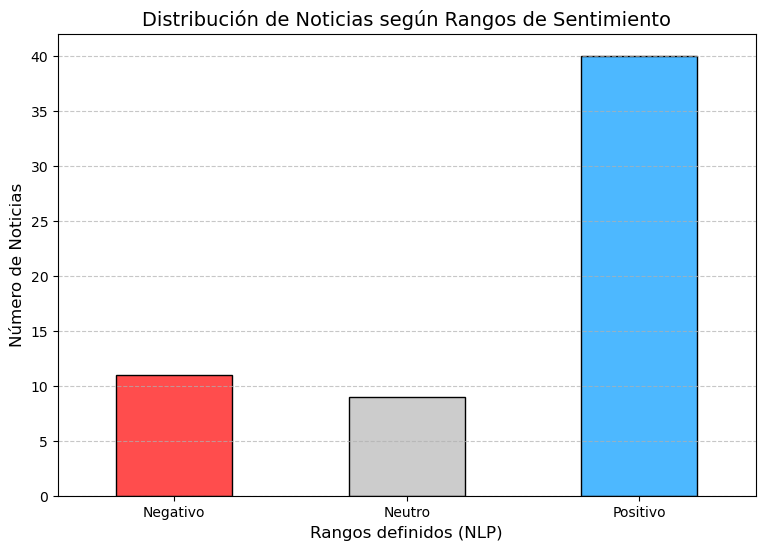

In [17]:
import matplotlib.pyplot as plt

def agrupar_sentimiento(score):
    if score <= -1:
        return 'Negativo'
    elif score <= 0:
        return 'Neutro'
    else:
        return 'Positivo'

# Crear la nueva columna en el DataSet
df_noticias['categoria_nlp'] = df_noticias['score_sentimiento'].apply(agrupar_sentimiento)

# Contar cuántas noticias hay en cada rango
conteos = df_noticias['categoria_nlp'].value_counts().reindex([
    'Negativo', 'Neutro', 'Positivo'
])

plt.figure(figsize=(9, 6))
colores = ['#ff4d4d', '#cccccc', '#4db8ff'] 

conteos.plot(kind='bar', color=colores, edgecolor='black')

plt.title('Distribución de Noticias según Rangos de Sentimiento', fontsize=14)
plt.xlabel('Rangos definidos (NLP)', fontsize=12)
plt.ylabel('Número de Noticias', fontsize=12)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

Se puede observar una franja de valores entre -3 y 2 en los pesos, se puede determinar que:

- Los valores bajos (-3, -2 y -1) se consideran un **sentimiento negativo** (Valores posibles como -4 e inferiones también)
- Los valores medios (0) se consideran un **sentiminto neutro**
- Los valores altos (1 y 2) se consideran un **sentimiento positivo** (Valores posibles como 3 y superiores también)

### Topic modeling de reportes de plagas

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Definimos una función sencilla para "etiquetar" temas
def categorizar_reporte(row):
    plaga = str(row['Plaga_detectada']).lower()
    tratamiento = str(row['Tratamiento_Aplicado']).lower()
    
    # Problemas de Hongos (Roya, Oídio, Mildiu)
    if any(h in plaga for h in ['roya', 'oídio', 'mildiu', 'fusarium']):
        return "Hongos y otros infecciosos"
    
    # Ataques de Insectos (Langosta, Mosca, Barrenador)
    elif any(i in plaga for i in ['langosta', 'mosca', 'oruga', 'barrenador', 'ácaro']):
        return "Infestación de Insectos"
    
    # Otros/General
    else:
        return "Otras Amenazas/ Asuntos politicos"

df_plagas['Tema_Detectado'] = df_plagas.apply(categorizar_reporte, axis=1)

# Ver cuántos reportes hay de cada "Tema"
resumen_temas = df_plagas['Tema_Detectado'].value_counts()
print(resumen_temas)

Tema_Detectado
Infestación de Insectos              48
Otras Amenazas/ Asuntos politicos    37
Hongos y otros infecciosos           15
Name: count, dtype: int64


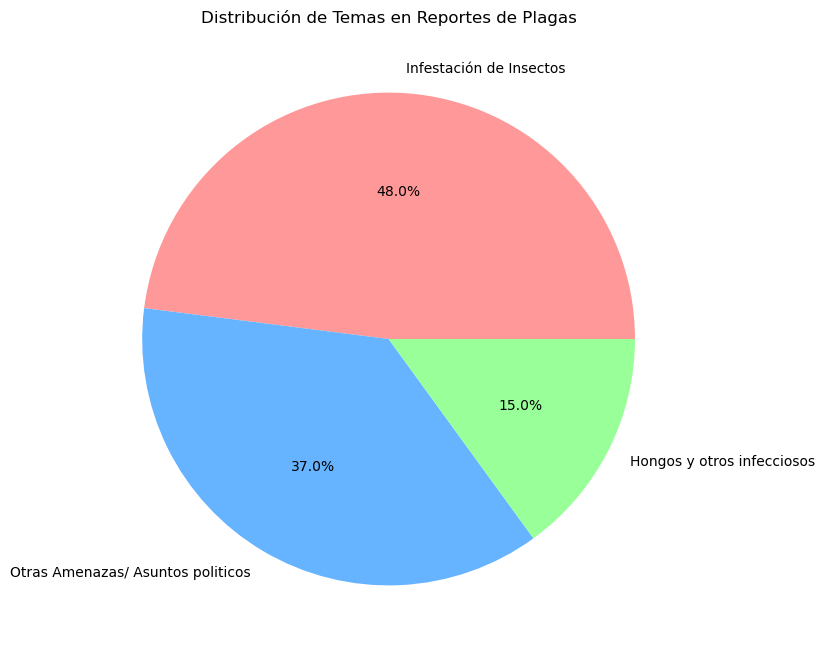

In [19]:
# Gráfico de tarta 
plt.figure(figsize=(8, 8))
resumen_temas.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribución de Temas en Reportes de Plagas')
plt.ylabel('') # Quitar etiqueta lateral para que quede limpio
plt.show()

Podemos ver en este grafico que la mayor cantidad de reportes sobre los cultivos son de infestaciones de insectos (48%), una minoria del 15% sobre hongos o enfermedades de las plantas y otras amenazas no controladas (37%).

Esto nos lleva a la conclusion de que la mayor amenaza de los cultivos suelen ser los insectos o amenazas externas tales como eventos extremos u otros mientras que los hongos e infecciones suelen estar mas controlados.

## Análisis de series temporales:

### Correlación entre noticias y precios de mercado

In [20]:
df_noticias.isnull().sum()

id_noticia           0
Alemania             0
Argentina            0
Australia            0
Brasil               0
Canadá               0
España               0
Estados Unidos       0
India                0
Italia               0
Francia              0
Kenia                0
México               0
Nueva Zelanda        0
Rusia                0
China                0
categoria            0
contenido            0
Año                  0
Mes                  0
Día                  0
fuente               0
impacto_cultivos     0
severidad            0
titular              0
contenido_limpio     0
score_sentimiento    0
categoria_nlp        0
dtype: int64

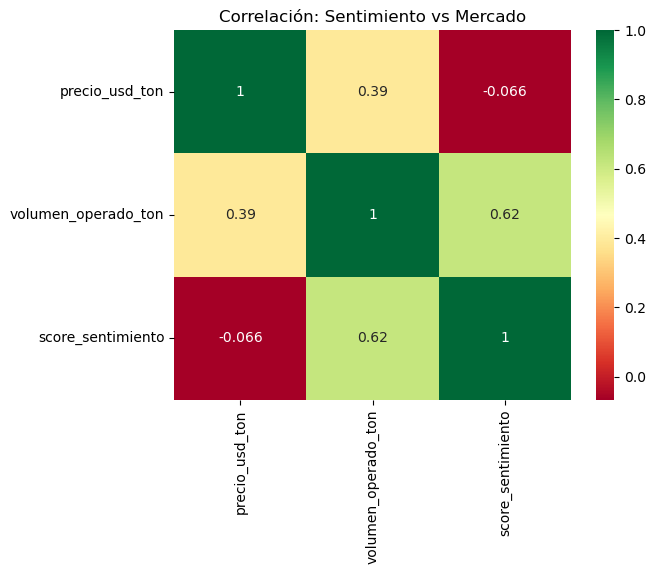

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mapeo de meses
meses_map = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
    'julio': 7, 'agosto': 8, 'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12
}
df_noticias['Mes_num'] = df_noticias['Mes'].str.lower().map(meses_map)

# Crear la fecha correcta
df_noticias['fecha'] = pd.to_datetime(pd.DataFrame({
    'year': df_noticias['Año'],
    'month': df_noticias['Mes_num'],
    'day': df_noticias['Día']
}))

# Agregamos los datos por MES (para que la correlación sea real)
noticias_mes = df_noticias.groupby(['Año', 'Mes_num', 'impacto_cultivos'])['score_sentimiento'].mean().reset_index()

# Precio y Volumen promedio mensual
df_precios['fecha'] = pd.to_datetime(df_precios['fecha'])
df_precios['Año'] = df_precios['fecha'].dt.year
df_precios['Mes'] = df_precios['fecha'].dt.month
precios_mes = df_precios.groupby(['Año', 'Mes', 'producto'])[['precio_usd_ton', 'volumen_operado_ton']].mean().reset_index()

# Unir y Correlación
df_corr = pd.merge(precios_mes, noticias_mes, left_on=['Año', 'Mes', 'producto'], right_on=['Año', 'Mes_num', 'impacto_cultivos'])
matriz = df_corr[['precio_usd_ton', 'volumen_operado_ton', 'score_sentimiento']].corr()

# Grafica
sns.heatmap(matriz, annot=True, cmap='RdYlGn')
plt.title('Correlación: Sentimiento vs Mercado')
plt.show()

La matriz de correlación muestra una **relación positiva fuerte** (0.62) entre el score de sentimiento y el volumen. Esto significa que cuando las noticias son positivas, hay más actividad en el mercado.

Hay una **relación moderada** (0.39) entre el precio y el volumen, cuando el precio sube, el volumen también lo haga (posiblemente por especulación o mayor oferta atraída por los precios altos).

Hay una **relación negativa devil** (0.066) entre el sentimiento y el precio, lo que es normal, ya que muchas de las noticias no suelen afectar directamente al precio del mercado de los productos

### Detección de alertas tempranas en reportes

Basandonos en los analisis antes hechos podemos deducir que el sentimiento es un predictor del volumen, esto nos permite hacer un analisis temprano basado en:

- Si el score de sentimiento cae por debajo de -2, el modelo puede predecir una contracción inminente en el volumen de mercado.

- Dado que el sentimiento no correlaciona con el precio, pero si afecta al volumen operado, es decir que al afectar a este, el precio si se ve reflejado en los cambios de mercado.

Por lo tanto, el sistema de alertas utiliza el volumen operado (0.62) como señal de validación. Cuando el modelo NLP detecta un sentimiento inferior a $-2$, el sistema emite una Alerta de Inestabilidad. Esta alerta permite a los usuarios anticiparse a los movimientos del mercado con una ventana de tiempo de un par de días, antes de que la crisis se traslade finalmente al precio por tonelada.

## Prospección

## Mercados 

### ¿Cómo responden los precios a noticias y eventos climáticos? 

In [22]:
df_clima = pd.read_csv('datos/condiciones_climaticas.csv')

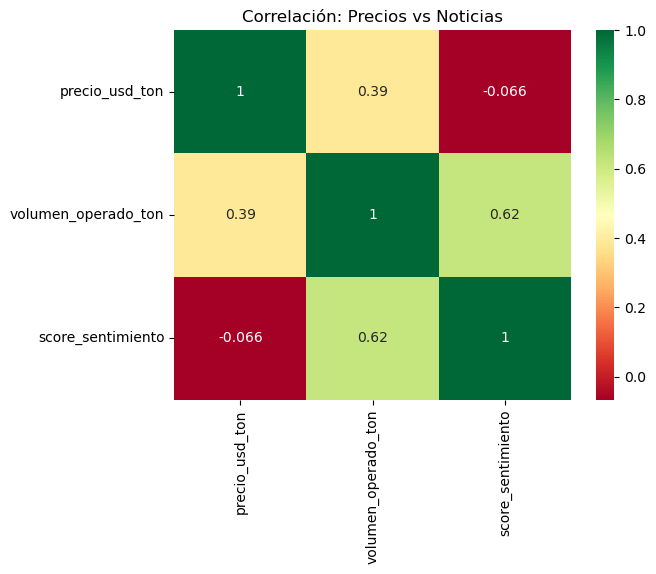

In [23]:
# Grafica
sns.heatmap(matriz, annot=True, cmap='RdYlGn')
plt.title('Correlación: Precios vs Noticias')
plt.show()

Como se ha podido ver antes, el precio y el sentimiento de la noticia (-0.066) practicamente no tienen relaccion entre ellos, sin embargo, si que influye en el volumen operado (0.62), lo que puede reflejar directamente cambios en el precio del mercado ya que el volumen y el precio si que estan relacionados.

In [24]:
# Estandarizar nombres de países (minúsculas y sin espacios)
df_precios['pais'] = df_precios['pais'].astype(str).str.lower().str.strip()
df_clima['pais'] = df_clima['pais'].astype(str).str.lower().str.strip()

In [25]:
# Mapeo de "Sin evento" en el dataset de clima
df_clima['eventos_extremos'] = df_clima['eventos_extremos'].fillna('Sin evento')

In [26]:
# Calculamos el perfil promedio de cada país
precios_global = df_precios.groupby('pais')[['precio_usd_ton', 'volumen_operado_ton']].mean().reset_index()

clima_global = df_clima.groupby('pais')[[
    'precipitacion_total', 'temperatura_promedio', 
    'indice_aridez', 'humedad_relativa_promedio', 
    'dias_con_heladas'
]].mean().reset_index()

In [27]:
df_global = pd.merge(precios_global, clima_global, on='pais')

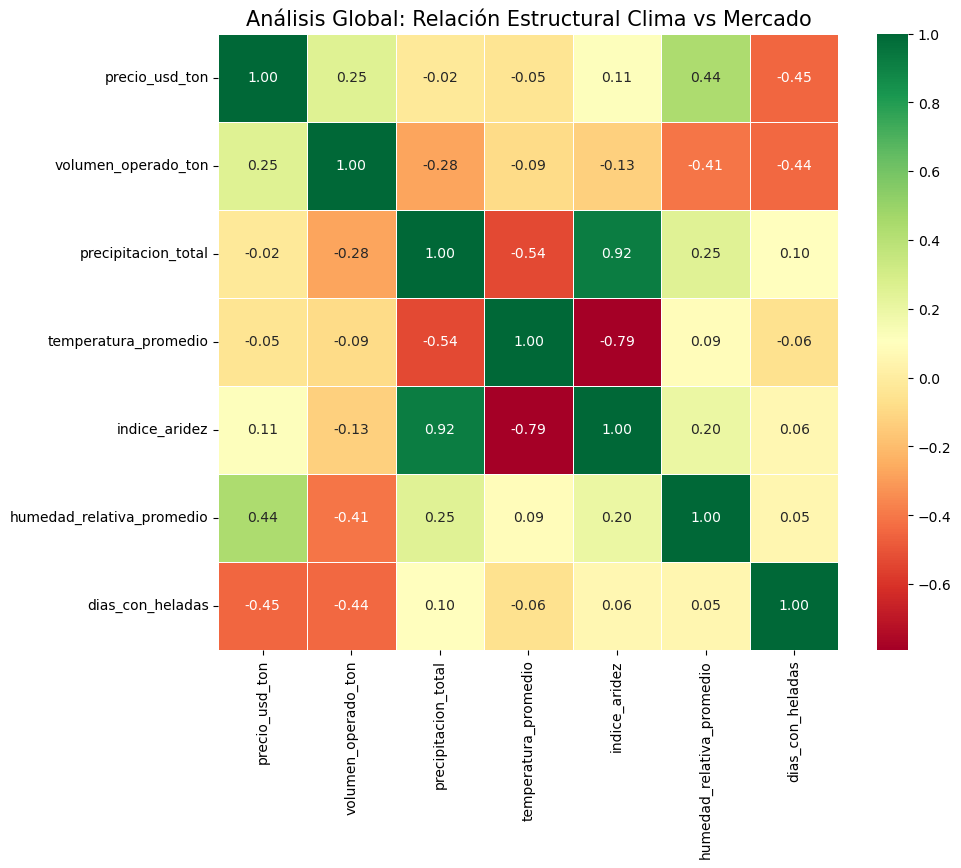

In [28]:
plt.figure(figsize=(10, 8))
# Calculamos la correlación entre las medias de cada país
matriz_global = df_global.drop(columns='pais').corr()

sns.heatmap(matriz_global, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Análisis Global: Relación Estructural Clima vs Mercado', fontsize=15)
plt.show()

### ¿Existen patrones de estacionalidad?

C:\Users\puebl\AppData\Local\Temp\ipykernel_20460\2116993397.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=estacionalidad_global, x='mes', y='precio_usd_ton', palette='magma')


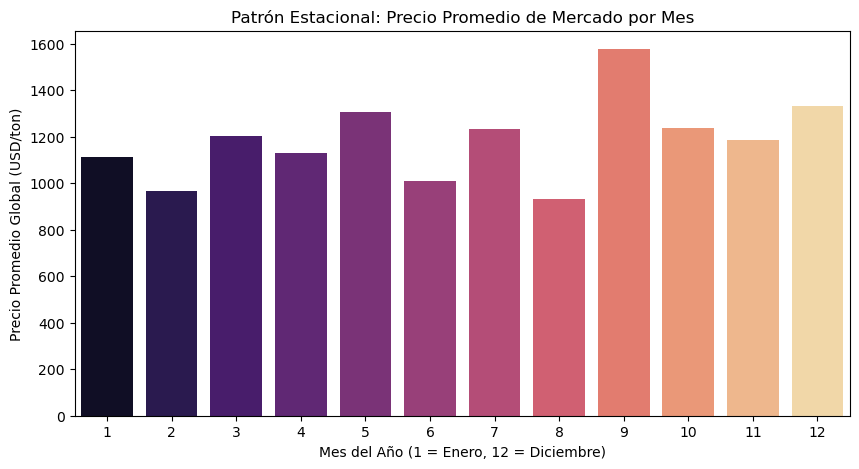

In [29]:
# Transformar la columna fecha para extraer el "Mes"
df_precios['fecha'] = pd.to_datetime(df_precios['fecha'])
df_precios['mes'] = df_precios['fecha'].dt.month

# Agrupar el precio promedio global por mes
estacionalidad_global = df_precios.groupby('mes')['precio_usd_ton'].mean().reset_index()

# Visualización
plt.figure(figsize=(10, 5))
sns.barplot(data=estacionalidad_global, x='mes', y='precio_usd_ton', palette='magma')

plt.title('Patrón Estacional: Precio Promedio de Mercado por Mes')
plt.xlabel('Mes del Año (1 = Enero, 12 = Diciembre)')
plt.ylabel('Precio Promedio Global (USD/ton)')
plt.show()

## Sanidad Vegetal 

### ¿Existe relación entre condiciones climáticas y brotes de plagas?

In [30]:
# Limpieza
df_plagas = df_plagas.rename(columns={'Pais': 'pais'})
df_clima['pais'] = df_clima['pais'].astype(str).str.upper().str.strip()
df_plagas['pais'] = df_plagas['pais'].astype(str).str.upper().str.strip()

In [31]:
df_clima_medio = df_clima.groupby('pais').agg({
    'temperatura_promedio': 'mean',
    'precipitacion_total': 'mean',
    'humedad_relativa_promedio': 'mean',
    'indice_aridez': 'mean'
}).reset_index()

In [32]:
df_plagas_medio = df_plagas.groupby('pais').agg({
    'Area_afectada': 'mean',
    'Perdida_estimada': 'mean',
    'Eficacia': 'mean'
}).reset_index()

In [33]:
df_perfil_pais = pd.merge(df_clima_medio, df_plagas_medio, on='pais')

In [34]:
matriz_corr = df_perfil_pais.drop(columns='pais').corr()

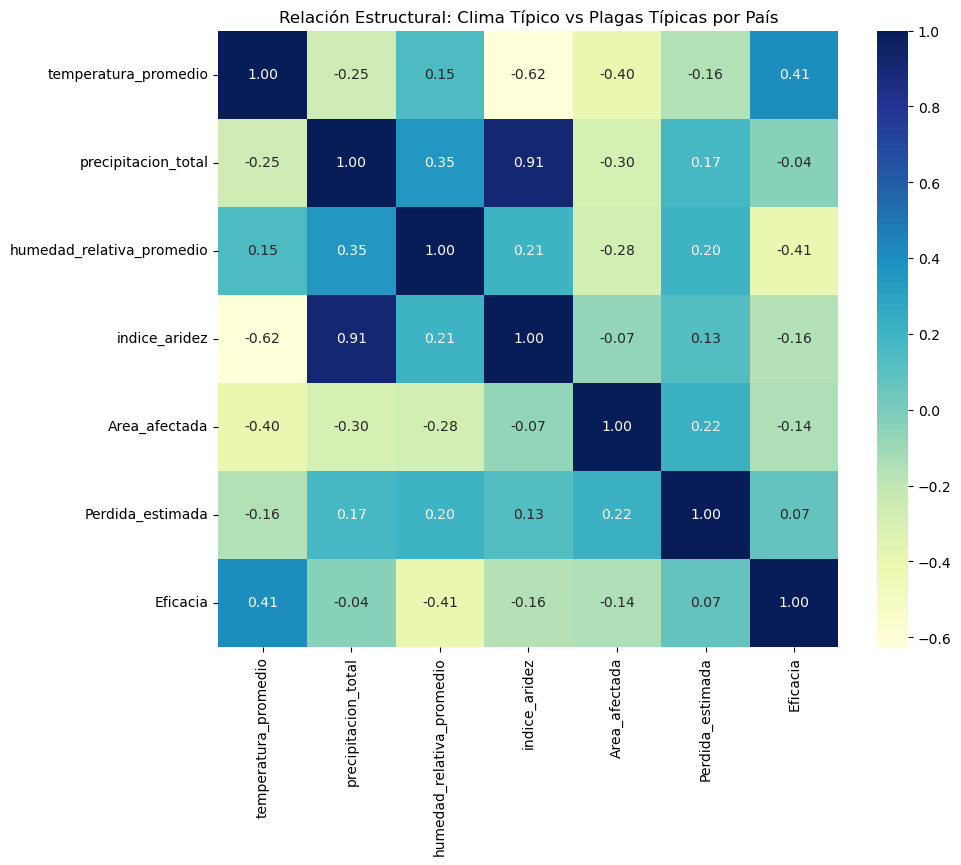

In [35]:
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Relación Estructural: Clima Típico vs Plagas Típicas por País')
plt.show()

### ¿Qué regiones tienen mayor riesgo?

In [36]:
# Agrupamos por Región y calculamos la media de la Pérdida Estimada y Área Afectada
# Usamos 'Perdida_estimada' como indicador principal de riesgo
riesgo_region = df_plagas.groupby('pais').agg({
    'Area_afectada': 'mean',
    'Perdida_estimada': 'mean'
}).sort_values(by='Perdida_estimada', ascending=False).reset_index()

C:\Users\puebl\AppData\Local\Temp\ipykernel_20460\3948414945.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=riesgo_region, x='Perdida_estimada', y='pais', palette='Reds_r')


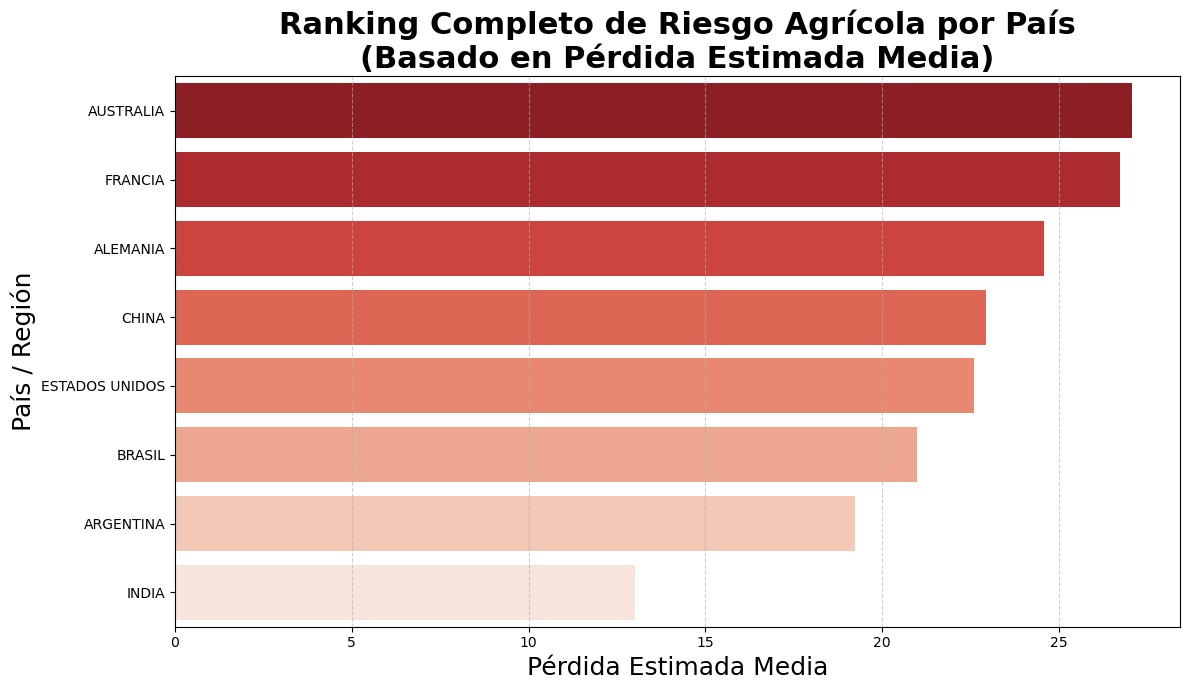

In [40]:
# Diseño del Gráfico de Barras Horizontal
plt.figure(figsize=(12, 7))
# Usamos una paleta roja invertida (los más oscuros arriba) para alertar del riesgo
sns.barplot(data=riesgo_region, x='Perdida_estimada', y='pais', palette='Reds_r')

plt.title('Ranking Completo de Riesgo Agrícola por País\n(Basado en Pérdida Estimada Media)', fontsize=22, fontweight='bold')
plt.xlabel('Pérdida Estimada Media', fontsize=18)
plt.ylabel('País / Región', fontsize=18)
plt.yticks(fontsize=10)

# Líneas de cuadrícula para facilitar la lectura de los valores
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()